# Import Packages

In [1]:
import numpy as np
import pandas as pd
import data_clean_utils
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [2]:
import dagshub
dagshub.init(repo_owner='inductive-anks1', repo_name='Swiggy-Delivery-Time-Prediction-DVC', mlflow=True)

Accessing as inductive-anks1

Initialized MLflow to track repo "inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC"

Repository inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC initialized!

In [3]:
from sklearn import set_config

set_config(transform_output="pandas")

# Load the Data

In [4]:
# load the data

df = pd.read_csv('../data/swiggy.csv')

# Clean Data

In [5]:
#data_clean_utils.perform_data_cleaning(df)

In [6]:
# load the cleaned data

df = pd.read_csv('../data/swiggy_cleaned.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [7]:
df.shape

(45502, 27)

In [8]:
df = df.sample(n=25000, random_state=42)

In [9]:
df.shape

(25000, 27)

In [10]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [11]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
40290,30.0,4.8,sunny,jam,1,buffet,scooter,1.0,no,metropolitian,18,0,10.0,night,12.417488,long
25035,23.0,5.0,fog,jam,2,buffet,scooter,1.0,no,metropolitian,36,0,15.0,night,NaN,NaN
2582,22.0,4.5,windy,low,2,drinks,scooter,0.0,no,metropolitian,14,1,5.0,night,4.406344,short
27641,27.0,4.5,sandstorms,medium,2,meal,motorcycle,1.0,no,metropolitian,23,0,15.0,afternoon,4.537513,short
44967,37.0,4.5,fog,medium,1,drinks,scooter,1.0,no,urban,17,0,10.0,afternoon,6.120942,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10897,29.0,4.0,fog,medium,1,buffet,scooter,0.0,no,metropolitian,34,1,15.0,afternoon,12.417792,long
5207,33.0,4.7,stormy,low,1,meal,scooter,1.0,no,metropolitian,25,0,10.0,night,4.560891,short
38338,23.0,4.6,sandstorms,low,0,meal,motorcycle,1.0,no,urban,24,0,15.0,night,13.630903,long
11299,22.0,4.8,sandstorms,jam,1,snack,scooter,1.0,no,metropolitian,17,1,5.0,night,17.076408,very_long


In [12]:
# check for missing values

df.isna().sum()

age                    1034
ratings                1070
weather                 279
traffic                 268
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     555
festival                122
city_type               651
time_taken                0
is_weekend                0
pickup_time_minutes     901
order_time_of_day      1150
distance               1996
distance_type          1996
dtype: int64

In [13]:
# check for duplicates

df.duplicated().sum()

0

<Axes: >

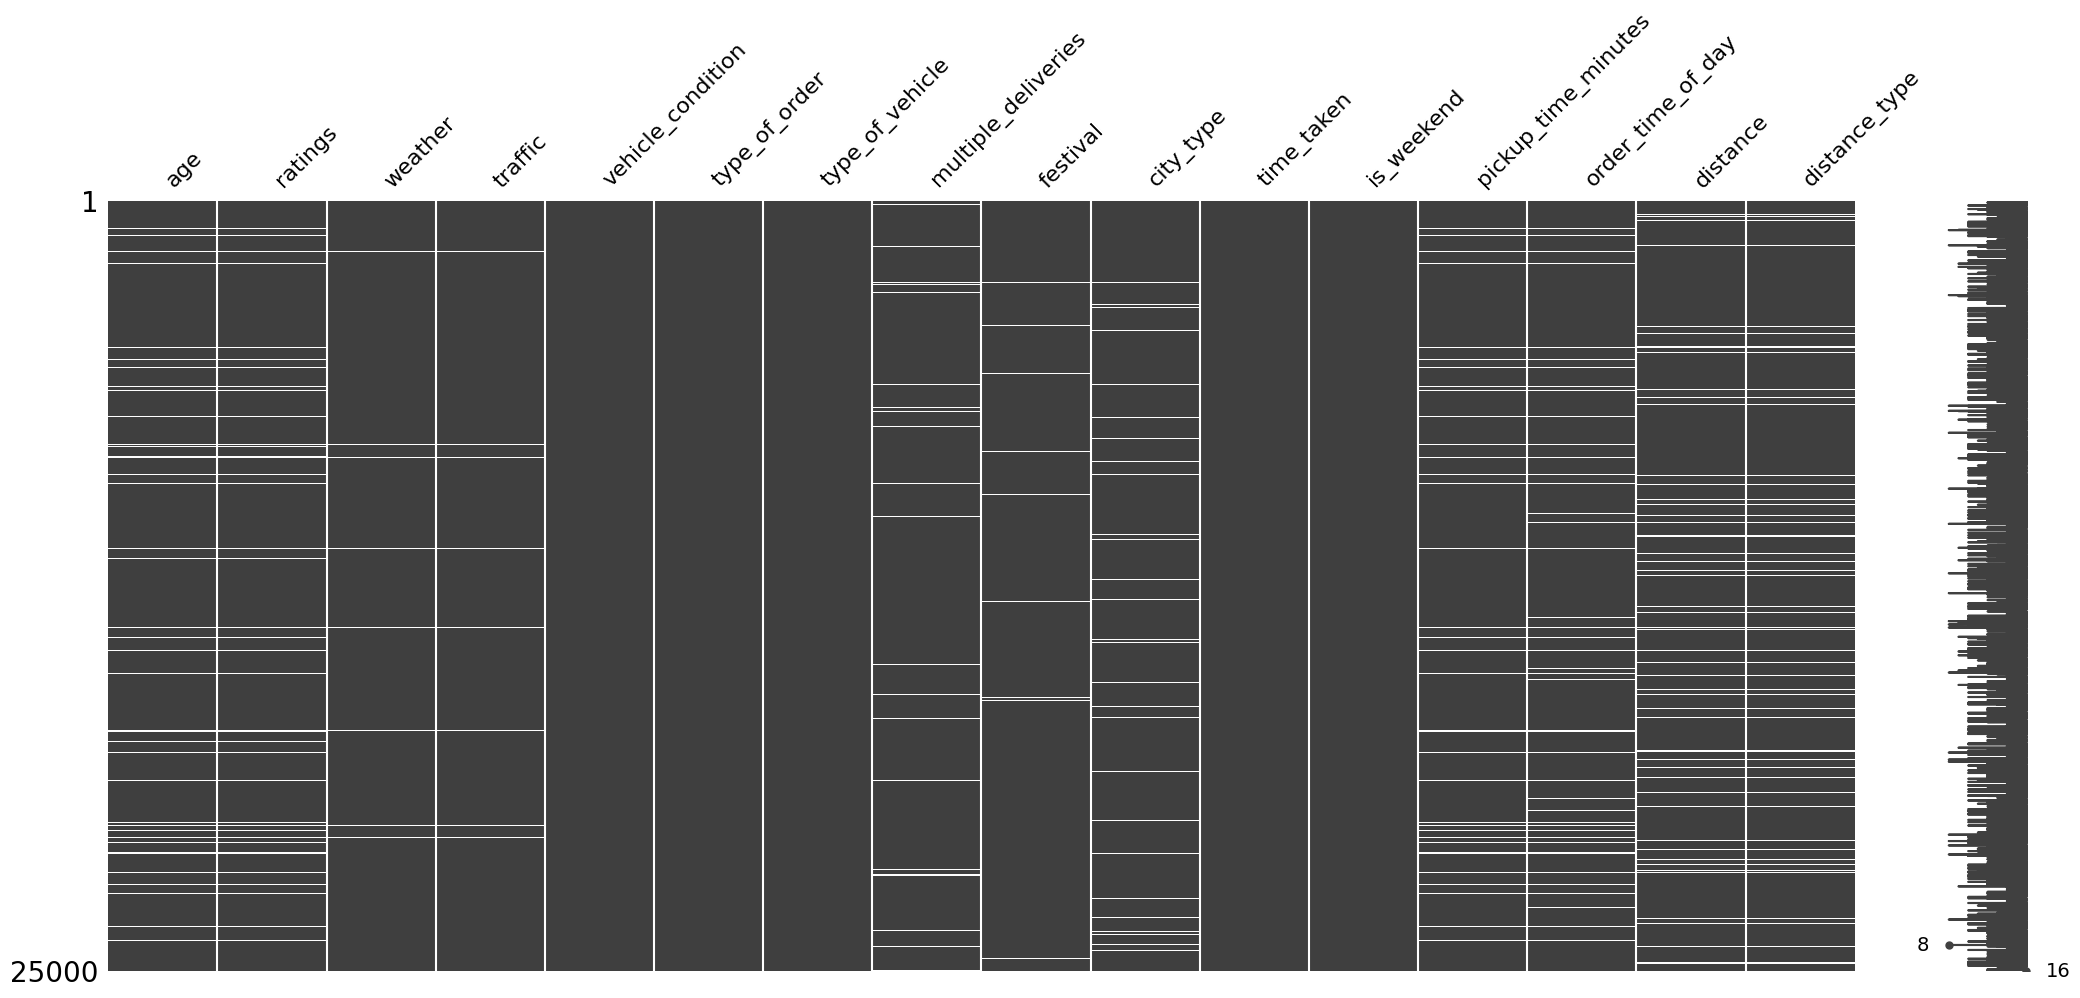

In [14]:
import missingno as msno

msno.matrix(df)

In [15]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

# Drop Missing Values



In [16]:
import mlflow

In [17]:
# set the tracking server

mlflow.set_tracking_uri("https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow")

In [18]:
# mlflow experiment

mlflow.set_experiment("Exp 1 - Keep Vs Drop Missing Values")

<Experiment: artifact_location='mlflow-artifacts:/4c8fd7a6ff4b4ddbb96f81d4629fd82d', creation_time=1736529155441, experiment_id='0', last_update_time=1736529155441, lifecycle_stage='active', name='Exp 1 - Keep Vs Drop Missing Values', tags={}>

In [19]:
temp_df = df.copy().dropna()

In [20]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
40290,30.0,4.8,sunny,jam,1,buffet,scooter,1.0,no,metropolitian,0,10.0,night,12.417488,long
2582,22.0,4.5,windy,low,2,drinks,scooter,0.0,no,metropolitian,1,5.0,night,4.406344,short
27641,27.0,4.5,sandstorms,medium,2,meal,motorcycle,1.0,no,metropolitian,0,15.0,afternoon,4.537513,short
44967,37.0,4.5,fog,medium,1,drinks,scooter,1.0,no,urban,0,10.0,afternoon,6.120942,medium
11090,39.0,4.6,sunny,jam,1,meal,scooter,1.0,no,metropolitian,0,10.0,evening,7.489981,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2792,31.0,4.7,sandstorms,low,2,buffet,scooter,0.0,no,metropolitian,1,5.0,night,4.656863,short
10897,29.0,4.0,fog,medium,1,buffet,scooter,0.0,no,metropolitian,1,15.0,afternoon,12.417792,long
5207,33.0,4.7,stormy,low,1,meal,scooter,1.0,no,metropolitian,0,10.0,night,4.560891,short
38338,23.0,4.6,sandstorms,low,0,meal,motorcycle,1.0,no,urban,0,15.0,night,13.630903,long


In [21]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (16549, 15)
The shape of test data is (4138, 15)


In [23]:
y_train

28585    25
43011    29
23971    42
29586    24
9621     31
         ..
27325    21
10604    22
8578     29
2059     22
20693    37
Name: time_taken, Length: 16549, dtype: int64

In [24]:
# missing data in training data

X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [25]:
X_train.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'is_weekend', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [26]:
len(X_train.columns)

15

In [27]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [28]:
len(num_cols + nominal_cat_cols + ordinal_cat_cols)

13

In [29]:
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['low' 'jam' 'medium' 'high']
distance_type ['very_long' 'long' 'short' 'medium']


In [30]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [31]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order]), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']]),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [32]:
# transform the data

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
28585,0.684211,0.88,0.0,0.938076,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3.0,2,0.0
43011,0.947368,0.96,0.5,0.563918,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,1,1.0
23971,0.315789,0.96,1.0,0.948906,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,3.0,0,2.0
29586,0.526316,0.92,0.0,0.004475,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1.0
9621,0.263158,0.64,0.0,0.944501,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27325,0.789474,0.92,0.5,0.084656,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1.0
10604,0.105263,0.88,0.5,0.613403,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,2,0.0
8578,0.210526,0.92,0.5,0.944363,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0,1.0
2059,0.421053,0.92,0.5,0.562492,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,3.0,2.0,1,1.0


In [33]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [34]:
pt.lambdas_

array([0.31301258])

In [35]:
y_train_pt

,x0
0,-0.054604
1,0.365937
2,1.511083
3,-0.166614
4,0.561852
...,...
16544,-0.522291
16545,-0.400221
16546,0.365937
16547,-0.400221


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train_trans,y_train_pt.values.ravel())

RandomForestRegressor()

In [37]:
# get the predictions
y_pred_train = rf.predict(X_train_trans)
y_pred_test = rf.predict(X_test_trans)

In [38]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.17 minutes
The test error is 3.14 minutes


In [40]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.97
The test r2 score is 0.82


In [41]:
# calculate the cross val score

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf,X_train_trans,y_train_pt.values.ravel(),cv=5,scoring="r2",n_jobs=-1)

scores

array([0.80042885, 0.79556601, 0.80452033, 0.79227033, 0.79962806])

In [42]:
# mean score

scores.mean()

0.7984827175105906

<Axes: >

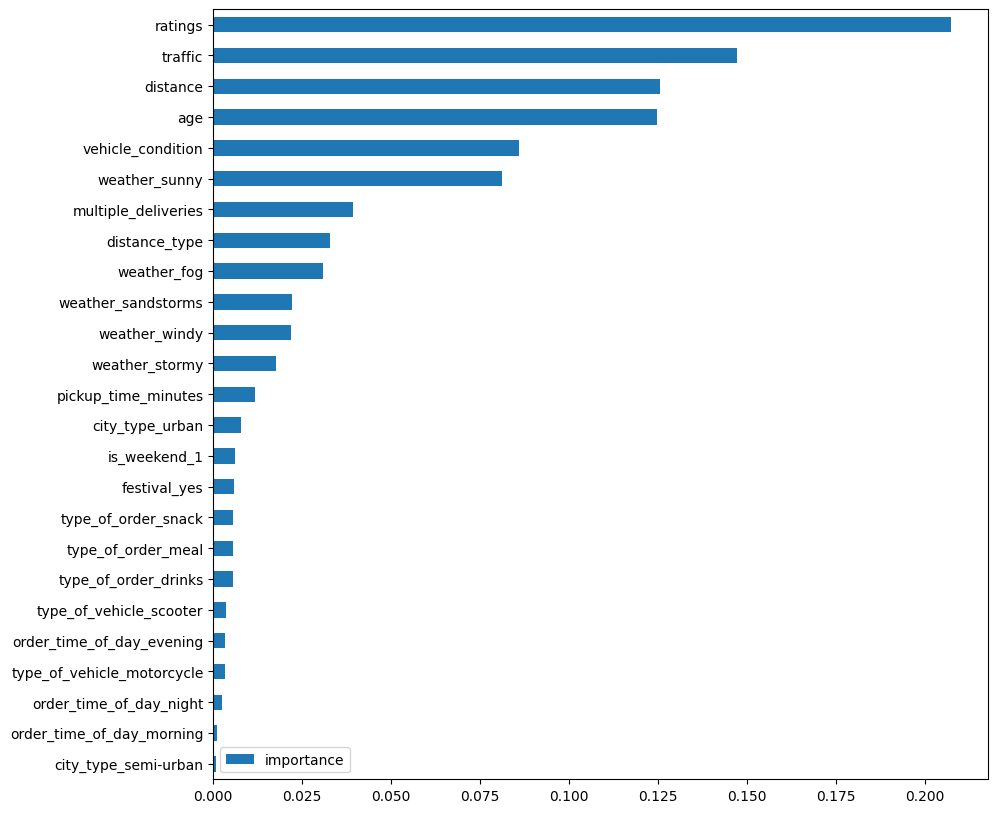

In [43]:
# feature importance plot

(
    pd.DataFrame(rf.feature_importances_,
             index=X_train_trans.columns,
             columns=["importance"])
    .sort_values(by="importance")
    .plot(kind='barh',figsize=(10,10))
)

In [44]:
# log experiment

with mlflow.start_run(run_name="Drop Missing Values"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type","Drop Missing Values")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val",scores.mean())


2025/01/13 14:35:05 INFO mlflow.tracking._tracking_service.client: 🏃 View run Drop Missing Values at: https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow/#/experiments/0/runs/82946a0bdc0c49fa9e53382c74bd0a3a.
2025/01/13 14:35:05 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow/#/experiments/0.


In [45]:
from sklearn.feature_selection import RFECV

In [46]:
# feature selection using rfecv

rfecv = RFECV(
    estimator=rf,
    step=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [47]:
# select features

rfecv.fit(X_train_trans,y_train_pt.values.ravel())

Fitting estimator with 25 features.
Fitting estimator with 25 features.
Fitting estimator with 25 features.
Fitting estimator with 25 features.
Fitting estimator with 25 features.
Fitting estimator with 15 features.
Fitting estimator with 15 features.
Fitting estimator with 15 features.
Fitting estimator with 15 features.
Fitting estimator with 15 features.
Fitting estimator with 5 features.
Fitting estimator with 5 features.
Fitting estimator with 5 features.
Fitting estimator with 5 features.
Fitting estimator with 5 features.


RFECV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1, scoring='r2', step=10,
      verbose=2)

In [48]:
# list of selected features

rfecv.get_feature_names_out()

array(['age', 'ratings', 'pickup_time_minutes', 'distance', 'weather_fog',
       'weather_sandstorms', 'weather_stormy', 'weather_sunny',
       'weather_windy', 'type_of_order_drinks', 'type_of_order_meal',
       'type_of_order_snack', 'type_of_vehicle_motorcycle',
       'type_of_vehicle_scooter', 'festival_yes', 'city_type_semi-urban',
       'city_type_urban', 'is_weekend_1', 'order_time_of_day_evening',
       'order_time_of_day_morning', 'order_time_of_day_night', 'traffic',
       'distance_type', 'vehicle_condition', 'multiple_deliveries'],
      dtype=object)

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(rfecv.transform(X_train_trans),y_train_pt.values.ravel())

RandomForestRegressor()

In [50]:
# get the predictions
y_pred_train = rf.predict(rfecv.transform(X_train_trans))
y_pred_test = rf.predict(rfecv.transform(X_test_trans))

In [51]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [52]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.17 minutes
The test error is 3.14 minutes


In [53]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.97
The test r2 score is 0.82


In [54]:
# calculate the cross val score

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf,rfecv.transform(X_train_trans),y_train_pt.values.ravel(),cv=5,scoring="r2",n_jobs=-1)

scores

array([0.80098759, 0.79577658, 0.80394536, 0.79216704, 0.80038386])

In [55]:
# mean score

scores.mean()

0.79865208886483

In [56]:
rf.feature_importances_

array([0.1248947 , 0.20848137, 0.01177245, 0.12251184, 0.03152826,
       0.02081017, 0.01800561, 0.08148869, 0.02287692, 0.00558686,
       0.0056639 , 0.00554783, 0.0034174 , 0.00351924, 0.00615312,
       0.00091236, 0.00792053, 0.0061975 , 0.00330499, 0.00128752,
       0.0023304 , 0.14692445, 0.03499189, 0.08542661, 0.0384454 ])

<Axes: >

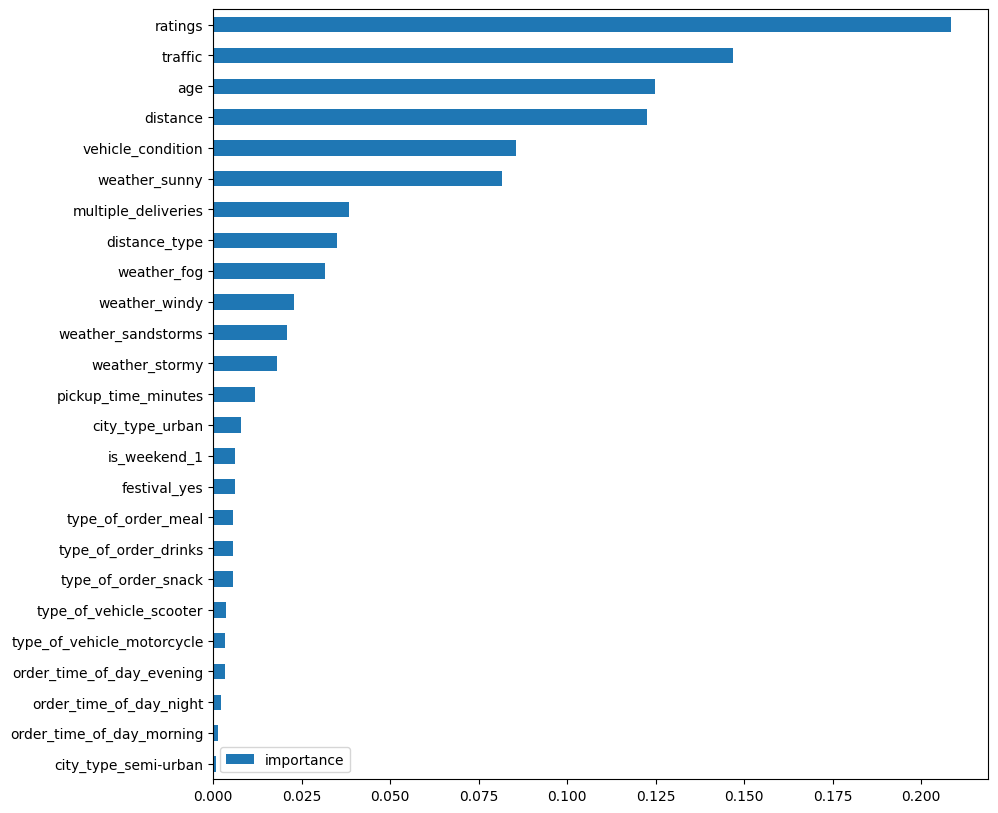

In [57]:
# feature importance plot

(
    pd.DataFrame(rf.feature_importances_,
             index=rfecv.transform(X_train_trans).columns,
             columns=["importance"])
    .sort_values(by="importance")
    .plot(kind='barh',figsize=(10,10))
)

# Impute Missing values

In [58]:
temp_df = df.copy()

In [59]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
40290,30.0,4.8,sunny,jam,1,buffet,scooter,1.0,no,metropolitian,0,10.0,night,12.417488,long
25035,23.0,5.0,fog,jam,2,buffet,scooter,1.0,no,metropolitian,0,15.0,night,NaN,NaN
2582,22.0,4.5,windy,low,2,drinks,scooter,0.0,no,metropolitian,1,5.0,night,4.406344,short
27641,27.0,4.5,sandstorms,medium,2,meal,motorcycle,1.0,no,metropolitian,0,15.0,afternoon,4.537513,short
44967,37.0,4.5,fog,medium,1,drinks,scooter,1.0,no,urban,0,10.0,afternoon,6.120942,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10897,29.0,4.0,fog,medium,1,buffet,scooter,0.0,no,metropolitian,1,15.0,afternoon,12.417792,long
5207,33.0,4.7,stormy,low,1,meal,scooter,1.0,no,metropolitian,0,10.0,night,4.560891,short
38338,23.0,4.6,sandstorms,low,0,meal,motorcycle,1.0,no,urban,0,15.0,night,13.630903,long
11299,22.0,4.8,sandstorms,jam,1,snack,scooter,1.0,no,metropolitian,1,5.0,night,17.076408,very_long


In [60]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (20000, 15)
The shape of test data is (5000, 15)


In [62]:
# missing values in train data

X_train.isna().sum()

age                     789
ratings                 815
weather                 210
traffic                 203
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     445
festival                102
city_type               534
is_weekend                0
pickup_time_minutes     685
order_time_of_day       886
distance               1571
distance_type          1571
dtype: int64

In [63]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [64]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [65]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


17.0

# Imputation Pipeline

In [66]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [67]:
X_train.isna().sum()

age                     789
ratings                 815
weather                 210
traffic                 203
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     445
festival                102
city_type               534
is_weekend                0
pickup_time_minutes     685
order_time_of_day       886
distance               1571
distance_type          1571
dtype: int64

In [68]:
# features to fill values with mode

features_to_fill_mode = ['multiple_deliveries','festival','city_type']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing

['weather',
 'type_of_order',
 'type_of_vehicle',
 'is_weekend',
 'order_time_of_day']

In [69]:
# simple imputer to fill categorical vars with mode

simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy="most_frequent"),features_to_fill_mode),
    ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing"),features_to_fill_missing)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'festival',
                                  'city_type']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'is_weekend', 'order_time_of_day'])],
                  verbose_feature_names_out=False)

In [70]:
simple_imputer.fit_transform(X_train)

,multiple_deliveries,festival,city_type,weather,type_of_order,type_of_vehicle,is_weekend,order_time_of_day,age,ratings,traffic,vehicle_condition,pickup_time_minutes,distance,distance_type
32600,0.0,no,metropolitian,windy,drinks,motorcycle,0,night,24.0,4.5,low,1,5.0,16.600976,very_long
35130,1.0,no,metropolitian,stormy,snack,motorcycle,1,morning,26.0,4.1,high,0,5.0,3.025280,short
657,1.0,no,metropolitian,cloudy,buffet,scooter,0,night,31.0,4.4,low,1,5.0,19.914687,very_long
2386,1.0,no,metropolitian,fog,snack,scooter,0,night,21.0,4.9,low,2,5.0,4.560891,short
34351,1.0,no,urban,sandstorms,snack,motorcycle,0,afternoon,29.0,5.0,medium,0,10.0,6.081204,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41011,0.0,no,metropolitian,fog,meal,scooter,0,evening,29.0,4.9,jam,2,5.0,4.469352,short
2649,0.0,no,metropolitian,fog,buffet,motorcycle,0,morning,32.0,4.6,low,0,15.0,1.532224,short
6769,0.0,no,metropolitian,windy,meal,motorcycle,0,evening,25.0,4.6,jam,0,15.0,12.243496,long
36601,1.0,no,urban,sandstorms,meal,motorcycle,0,night,27.0,4.8,low,0,10.0,12.352640,long


In [71]:
simple_imputer.fit_transform(X_train).isna().sum()

multiple_deliveries       0
festival                  0
city_type                 0
weather                   0
type_of_order             0
type_of_vehicle           0
is_weekend                0
order_time_of_day         0
age                     789
ratings                 815
traffic                 203
vehicle_condition         0
pickup_time_minutes     685
distance               1571
distance_type          1571
dtype: int64

In [72]:
# knn imputer

knn_imputer = KNNImputer(n_neighbors=5)

In [73]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [74]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [75]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['low' 'high' 'medium' 'jam' nan]
distance_type ['very_long' 'short' 'medium' 'long' nan]


In [76]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [77]:
preprocessor.fit_transform(X_train)

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,weather_nan,...,city_type_nan,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,order_time_of_day_nan,traffic,distance_type,vehicle_condition,multiple_deliveries
32600,0.210526,0.80,0.0,0.776024,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,1,0.0
35130,0.315789,0.64,0.0,0.079993,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,0,1.0
657,0.578947,0.76,0.0,0.945920,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,1,1.0
2386,0.052632,0.96,0.0,0.158724,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2,1.0
34351,0.473684,1.00,0.5,0.236671,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41011,0.473684,0.96,0.0,0.154031,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,2,0.0
2649,0.631579,0.84,1.0,0.003443,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
6769,0.263158,0.84,1.0,0.552615,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3.0,2.0,0,0.0
36601,0.368421,0.92,0.5,0.558210,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0,1.0


In [78]:
preprocessor.fit_transform(X_train).isna().sum().loc[lambda ser : ser.ge(1)]

age                     789
ratings                 815
pickup_time_minutes     685
distance               1571
multiple_deliveries     445
dtype: int64

In [79]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor),
                                ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['multiple_deliveries',
                                                   'festival', 'city_type']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehi...
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [80]:
model_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",rf)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor())])

In [81]:
# fit the pipeline on data

model_pipe.fit(X_train,y_train_pt.values.ravel())

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor())])

In [82]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [83]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [84]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.24 minutes
The test error is 3.39 minutes


In [85]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.97
The test r2 score is 0.79


In [86]:
# calculate the cross val score

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_pipe,X_train,y_train_pt.values.ravel(),cv=5,scoring="r2",n_jobs=-1)

scores

array([0.76991121, 0.76503456, 0.7661775 , 0.77763947, 0.77405326])

In [87]:
# mean score

scores.mean()

0.7705632000940488

In [88]:
# log experiment

with mlflow.start_run(run_name="Impute Missing Values"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type","Impute Missing Values")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val",scores.mean())

2025/01/13 14:39:24 INFO mlflow.tracking._tracking_service.client: 🏃 View run Impute Missing Values at: https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow/#/experiments/0/runs/884a9975503b4a19b54e895ee794108f.
2025/01/13 14:39:24 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow/#/experiments/0.
